# 04. Deep Learning Models

This notebook rebuilds the deep-learning analysis as a real training notebook. It trains `LSTM`, `NBEATS`, and `NHITS` directly from raw data using a standardized deep-learning subset, evaluates them on a rolling post-cutoff validation window, and compares the fresh DL predictions against the saved `LightGBM` benchmark on the exact same rows.

**Executive summary**
- This notebook is a true retrain notebook, not just a parquet-reader.
- The DL setup uses target history only, so it tests a different modeling hypothesis from the ML notebook.
- To make rolling validation feasible, the notebook standardizes to series with at least `32` pre-cutoff and `32` post-cutoff observations.
- The notebook remains point-forecast-only: no quantiles, intervals, `PICP`, or `MPIW` are added here.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from neuralforecast import NeuralForecast
from neuralforecast.models import LSTM, NBEATS, NHITS

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

PROJECT_ROOT = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
DATA_DIR = PROJECT_ROOT / 'data/ts-forecasting'
PROCESSED_DIR = PROJECT_ROOT / 'data/processed'

VAL_CUTOFF = 2880
DL_INPUT_SIZE = 32
DL_TEST_SIZE = 32
SEED = 42
series_keys = ['code', 'sub_code', 'sub_category', 'horizon']

train = pd.read_parquet(DATA_DIR / 'train.parquet', columns=series_keys + ['ts_index', 'y_target', 'weight'])
train = train.sort_values(series_keys + ['ts_index']).reset_index(drop=True)


def weighted_skill(y_true, y_pred, weight):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    weight = np.asarray(weight, dtype=float)
    denom = np.sum(weight * (y_true ** 2))
    if denom == 0:
        return np.nan
    ratio = np.sum(weight * ((y_true - y_pred) ** 2)) / denom
    ratio = min(max(ratio, 0.0), 1.0)
    return float(np.sqrt(1.0 - ratio))


def weighted_rmse(y_true, y_pred, weight):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    weight = np.asarray(weight, dtype=float)
    denom = np.sum(weight)
    if denom == 0:
        return np.nan
    return float(np.sqrt(np.sum(weight * ((y_true - y_pred) ** 2)) / denom))


def weighted_mae(y_true, y_pred, weight):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    weight = np.asarray(weight, dtype=float)
    denom = np.sum(weight)
    if denom == 0:
        return np.nan
    return float(np.sum(weight * np.abs(y_true - y_pred)) / denom)


def metric_table(df, model_cols, y_col='y', weight_col='weight'):
    rows = []
    baseline_weighted_rms = float(np.sqrt(np.sum(df[weight_col] * (df[y_col] ** 2)) / np.sum(df[weight_col])))
    for model in model_cols:
        numer = np.sum(df[weight_col] * ((df[y_col] - df[model]) ** 2))
        denom = np.sum(df[weight_col] * (df[y_col] ** 2))
        rows.append({
            'model': model,
            'skill_score': weighted_skill(df[y_col], df[model], df[weight_col]),
            'rmse': weighted_rmse(df[y_col], df[model], df[weight_col]),
            'mae': weighted_mae(df[y_col], df[model], df[weight_col]),
            'mse_ratio_vs_weighted_target_energy': float(numer / denom) if denom else np.nan,
            'weighted_target_rms': baseline_weighted_rms,
        })
    return pd.DataFrame(rows)

train.head()

,code,sub_code,sub_category,horizon,ts_index,y_target,weight
0,10BAVIDU,236HB58W,DPPUO5X2,1,3531,-2.795824,0.032189
1,10BAVIDU,236HB58W,DPPUO5X2,1,3532,-1.250105,0.032876
2,10BAVIDU,236HB58W,DPPUO5X2,1,3533,4.685167,0.032329
3,10BAVIDU,236HB58W,DPPUO5X2,1,3534,-0.159681,0.033005
4,10BAVIDU,236HB58W,DPPUO5X2,1,3535,-1.256449,0.033736


## 1. Why this notebook is different from the ML notebook

The ML notebook uses exogenous features and engineered target-history features in a tabular setup. This notebook does not. Here we intentionally test whether **history-only global neural models** can learn enough shared temporal structure across many series to compete on the same forecasting task. That makes this notebook a complementary experiment, not a direct replacement for the ML pipeline.

## 2. Deep-learning eligibility and standardized evaluation window

Not every series that crosses the cutoff is suitable for a clean rolling DL evaluation. NeuralForecast needs enough pre-cutoff history to form input windows and a common post-cutoff span to evaluate consistently across models. We therefore keep only series with at least `32` pre-cutoff observations and `32` post-cutoff observations.

In [2]:
series_meta = (
    train.groupby(series_keys)['ts_index']
         .agg(min_ts='min', max_ts='max', total_len='size')
         .reset_index()
)
pre_len = train[train['ts_index'] <= VAL_CUTOFF].groupby(series_keys)['ts_index'].size().rename('train_len').reset_index()
post_len = train[train['ts_index'] > VAL_CUTOFF].groupby(series_keys)['ts_index'].size().rename('val_len').reset_index()
series_meta = series_meta.merge(pre_len, on=series_keys, how='left').merge(post_len, on=series_keys, how='left').fillna({'train_len': 0, 'val_len': 0})
series_meta['crosses_cutoff'] = (series_meta['min_ts'] <= VAL_CUTOFF) & (series_meta['max_ts'] > VAL_CUTOFF)

dl_eligible_meta = series_meta[
    (series_meta['crosses_cutoff'])
    & (series_meta['train_len'] >= DL_INPUT_SIZE)
    & (series_meta['val_len'] >= DL_TEST_SIZE)
].copy()

dl_scope_summary = {
    'all_series': int(len(series_meta)),
    'crossing_series': int(series_meta['crosses_cutoff'].sum()),
    'dl_eligible_series': int(len(dl_eligible_meta)),
    'required_pre_cutoff_len': DL_INPUT_SIZE,
    'required_post_cutoff_len': DL_TEST_SIZE,
}
dl_scope_summary

{'all_series': 36923,
 'crossing_series': 1930,
 'dl_eligible_series': 1154,
 'required_pre_cutoff_len': 32,
 'required_post_cutoff_len': 32}

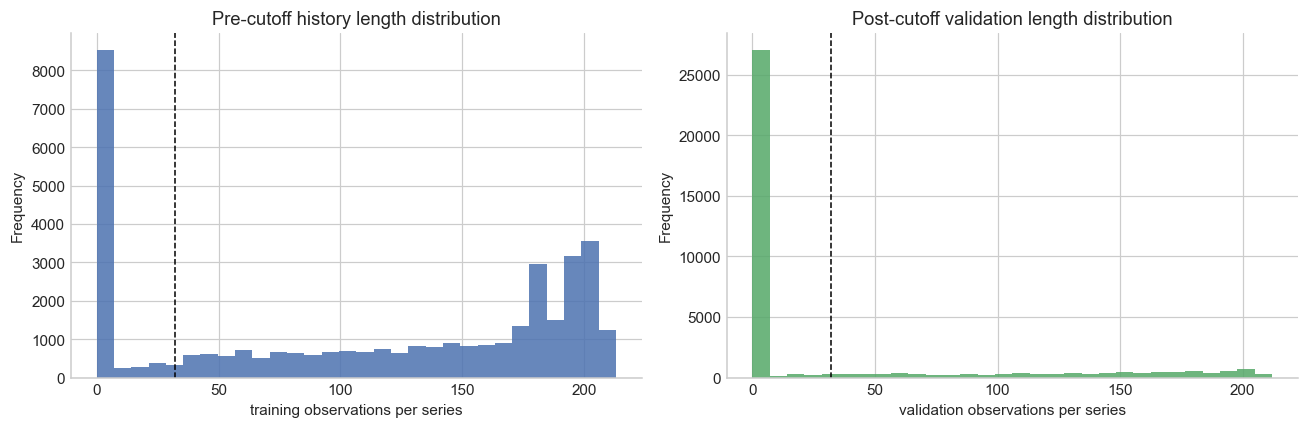

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

series_meta['train_len'].plot.hist(ax=axes[0], bins=30, color='#4C72B0', alpha=0.85)
axes[0].axvline(DL_INPUT_SIZE, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Pre-cutoff history length distribution')
axes[0].set_xlabel('training observations per series')

series_meta['val_len'].plot.hist(ax=axes[1], bins=30, color='#55A868', alpha=0.85)
axes[1].axvline(DL_TEST_SIZE, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Post-cutoff validation length distribution')
axes[1].set_xlabel('validation observations per series')

plt.tight_layout()
plt.show()

The DL notebook therefore works on a **standardized DL-eligible subset**, not on every crossing series. That is the price of making rolling one-step validation decision-complete and reproducible inside a single notebook.

## 3. Panel construction for NeuralForecast

NeuralForecast expects a panel in `unique_id / ds / y` format. We build that panel from raw train data, but we also retain a metadata lookup so the resulting predictions can be joined back to `weight`, `sub_category`, `horizon`, and the saved ML benchmark later.

In [4]:
panel = train.merge(dl_eligible_meta[series_keys], on=series_keys, how='inner').copy()
panel['unique_id'] = panel[series_keys].astype(str).agg('__'.join, axis=1)
panel = panel.rename(columns={'ts_index': 'ds', 'y_target': 'y'})
panel = panel.sort_values(['unique_id', 'ds']).reset_index(drop=True)

nf_df = panel[['unique_id', 'ds', 'y']].copy()
meta_lookup = panel[['unique_id', 'code', 'sub_code', 'sub_category', 'horizon']].drop_duplicates().copy()

eval_lookup = panel[['unique_id', 'ds', 'weight', 'code', 'sub_code', 'sub_category', 'horizon']].copy()
eval_lookup['rank_desc'] = eval_lookup.groupby('unique_id')['ds'].rank(method='first', ascending=False)
eval_lookup = eval_lookup[eval_lookup['rank_desc'] <= DL_TEST_SIZE].drop(columns='rank_desc').copy()

panel_summary = {
    'panel_rows': int(len(panel)),
    'unique_ids': int(panel['unique_id'].nunique()),
    'eval_rows_expected': int(len(eval_lookup)),
}
panel_summary

{'panel_rows': 210329, 'unique_ids': 1154, 'eval_rows_expected': 36928}

## 4. Model definitions

We keep the same three model families used in the project story:
- `LSTM` for sequential memory and nonlinear persistence
- `NBEATS` for stacked backcast/forecast decomposition blocks
- `NHITS` for hierarchical interpolation over multiple temporal resolutions

The configs below are intentionally fixed and moderate. This notebook is a reproducible comparison notebook, not a hyperparameter search notebook.

In [5]:
common_trainer_kwargs = dict(
    enable_progress_bar=False,
    logger=False,
    enable_model_summary=False,
)

models = [
    LSTM(
        h=1,
        input_size=DL_INPUT_SIZE,
        encoder_hidden_size=64,
        decoder_hidden_size=64,
        batch_size=64,
        windows_batch_size=128,
        learning_rate=1e-3,
        max_steps=40,
        scaler_type='robust',
        random_seed=SEED,
        alias='LSTM',
        **common_trainer_kwargs,
    ),
    NBEATS(
        h=1,
        input_size=DL_INPUT_SIZE,
        stack_types=['identity', 'identity', 'identity'],
        n_blocks=[1, 1, 1],
        mlp_units=[[128, 128], [128, 128], [128, 128]],
        batch_size=64,
        windows_batch_size=256,
        learning_rate=1e-3,
        max_steps=40,
        scaler_type='identity',
        random_seed=SEED,
        alias='NBEATS',
        **common_trainer_kwargs,
    ),
    NHITS(
        h=1,
        input_size=DL_INPUT_SIZE,
        n_blocks=[1, 1, 1],
        mlp_units=[[128, 128], [128, 128], [128, 128]],
        n_pool_kernel_size=[2, 2, 1],
        n_freq_downsample=[4, 2, 1],
        batch_size=64,
        windows_batch_size=256,
        learning_rate=1e-3,
        max_steps=40,
        scaler_type='identity',
        random_seed=SEED,
        alias='NHITS',
        **common_trainer_kwargs,
    ),
]

pd.DataFrame([
    {'model': 'LSTM', 'input_size': DL_INPUT_SIZE, 'max_steps': 40},
    {'model': 'NBEATS', 'input_size': DL_INPUT_SIZE, 'max_steps': 40},
    {'model': 'NHITS', 'input_size': DL_INPUT_SIZE, 'max_steps': 40},
])

Seed set to 42


Seed set to 42


Seed set to 42


,model,input_size,max_steps
0,LSTM,32,40
1,NBEATS,32,40
2,NHITS,32,40


## 5. Rolling post-cutoff validation

We use NeuralForecast rolling cross-validation with `h = 1` and `test_size = 32`. That means each model is trained once on the pre-evaluation history and then rolled forward one step at a time across the last `32` observations of each eligible series.

In [6]:
nf = NeuralForecast(models=models, freq=1)
dl_cv = nf.cross_validation(
    df=nf_df,
    n_windows=None,
    test_size=DL_TEST_SIZE,
    step_size=1,
    val_size=0,
    refit=False,
)

dl_eval = dl_cv.merge(eval_lookup, on=['unique_id', 'ds'], how='left', validate='one_to_one')
dl_eval = dl_eval.sort_values(['unique_id', 'ds']).reset_index(drop=True)

assert dl_eval[['weight', 'sub_category', 'horizon']].notna().all().all()
assert len(dl_eval) == len(eval_lookup)

dl_eval.head()

GPU available: True (mps), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


`Trainer.fit` stopped: `max_steps=40` reached.


GPU available: True (mps), used: True


...

`Trainer.fit` stopped: `max_steps=40` reached.


GPU available: True (mps), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


,unique_id,ds,cutoff,LSTM,NBEATS,NHITS,y,weight,code,sub_code,sub_category,horizon
0,1HEMHZK2__5AIUJMDO__DPPUO5X2__1,2903,2902,-0.000530,0.002710,-0.001961,-0.000363,3.523742e+06,1HEMHZK2,5AIUJMDO,DPPUO5X2,1
1,1HEMHZK2__5AIUJMDO__DPPUO5X2__1,2904,2903,-0.000664,0.004059,-0.000552,0.004372,3.495233e+06,1HEMHZK2,5AIUJMDO,DPPUO5X2,1
2,1HEMHZK2__5AIUJMDO__DPPUO5X2__1,2905,2904,0.000336,0.008595,0.003934,0.008936,3.582637e+06,1HEMHZK2,5AIUJMDO,DPPUO5X2,1
3,1HEMHZK2__5AIUJMDO__DPPUO5X2__1,2906,2905,0.001616,0.013085,0.008274,-0.004638,3.561188e+06,1HEMHZK2,5AIUJMDO,DPPUO5X2,1
4,1HEMHZK2__5AIUJMDO__DPPUO5X2__1,2907,2906,0.001033,0.000021,-0.004710,-0.001099,3.539995e+06,1HEMHZK2,5AIUJMDO,DPPUO5X2,1


## 6. Overall validation metrics

The bounded skill score is reported for consistency with the rest of the project, but it is not enough on its own. When the weighted target RMS is very small, the bounded score can clip to zero even though RMSE and MAE still separate the models.

In [7]:
dl_models = ['LSTM', 'NBEATS', 'NHITS']
deep_metrics = metric_table(dl_eval, dl_models, y_col='y', weight_col='weight')
deep_metrics

,model,skill_score,rmse,mae,mse_ratio_vs_weighted_target_energy,weighted_target_rms
0,LSTM,0.607257,0.003518,0.000619,0.631239,0.004427
1,NBEATS,0.000000,0.005368,0.004559,1.469985,0.004427
2,NHITS,0.749832,0.002929,0.000552,0.437751,0.004427


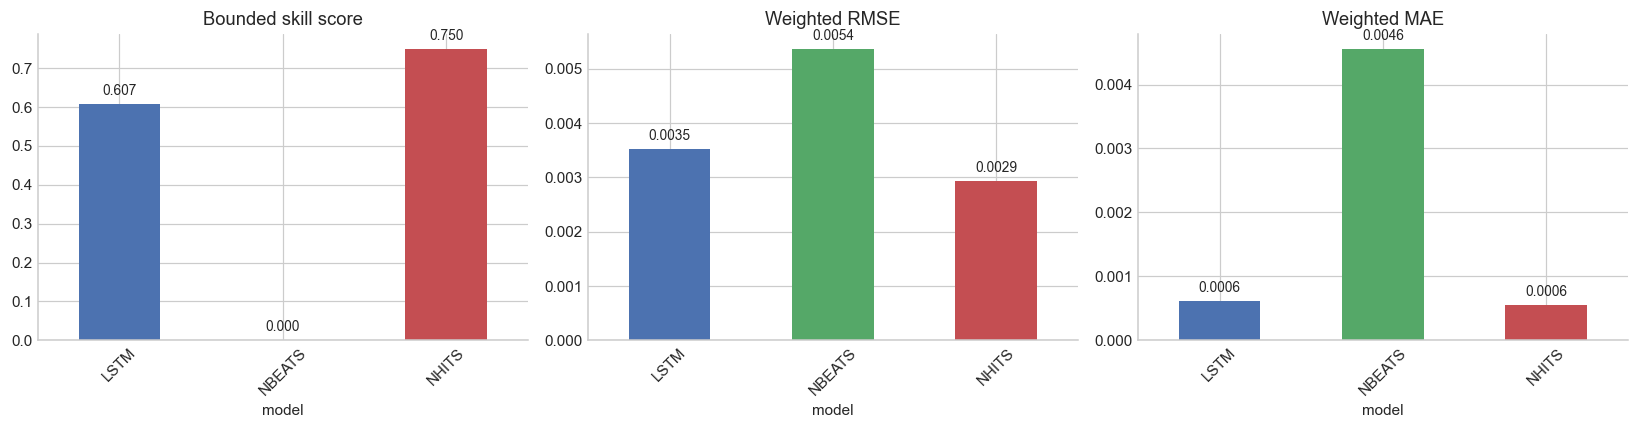

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric, title, fmt in zip(
    axes,
    ['skill_score', 'rmse', 'mae'],
    ['Bounded skill score', 'Weighted RMSE', 'Weighted MAE'],
    ['{:.3f}', '{:.4f}', '{:.4f}'],
):
    deep_metrics.set_index('model')[metric].plot.bar(ax=ax, color=['#4C72B0', '#55A868', '#C44E52'])
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=45)
    for patch, value in zip(ax.patches, deep_metrics[metric]):
        ax.annotate(fmt.format(value), (patch.get_x() + patch.get_width() / 2, patch.get_height()), ha='center', va='bottom', xytext=(0, 4), textcoords='offset points', fontsize=9)
    if metric == 'skill_score' and float(deep_metrics[metric].max()) == 0.0:
        ax.text(0.5, 0.5, 'All DL models are above the\nweighted target RMS baseline,\nso skill clips to 0.', transform=ax.transAxes, ha='center', va='center', fontsize=9)
        ax.set_ylim(0, 0.05)
plt.tight_layout()
plt.show()

The main DL ranking should therefore be read from RMSE and MAE, not from the clipped bounded skill alone. That is the same issue we saw in the ML notebook when the normalized target energy became extremely small.

## 7. Same-row LightGBM benchmark

To make the DL vs ML comparison more concrete, we join the saved `LightGBM` predictions from the ML pipeline onto the **exact same DL evaluation rows**. This is the fairest benchmark available without retraining LightGBM inside this notebook.

In [9]:
ml_ref = pd.read_parquet(PROCESSED_DIR / 'ml_val_preds.parquet')
ml_ref = ml_ref.rename(columns={'ts_index': 'ds'})

same_row_ref = dl_eval.merge(
    ml_ref[['code', 'sub_code', 'sub_category', 'horizon', 'ds', 'lgb_pred', 'xgb_pred']],
    on=['code', 'sub_code', 'sub_category', 'horizon', 'ds'],
    how='left',
    validate='one_to_one',
)

benchmark_metrics = metric_table(same_row_ref, ['LSTM', 'NBEATS', 'NHITS', 'lgb_pred'], y_col='y', weight_col='weight')
benchmark_metrics = benchmark_metrics.replace({'lgb_pred': 'LightGBM'})
benchmark_metrics

,model,skill_score,rmse,mae,mse_ratio_vs_weighted_target_energy,weighted_target_rms
0,LSTM,0.607257,0.003518,0.000619,0.631239,0.004427
1,NBEATS,0.000000,0.005368,0.004559,1.469985,0.004427
2,NHITS,0.749832,0.002929,0.000552,0.437751,0.004427
3,LightGBM,0.996010,0.000395,0.000033,0.007964,0.004427


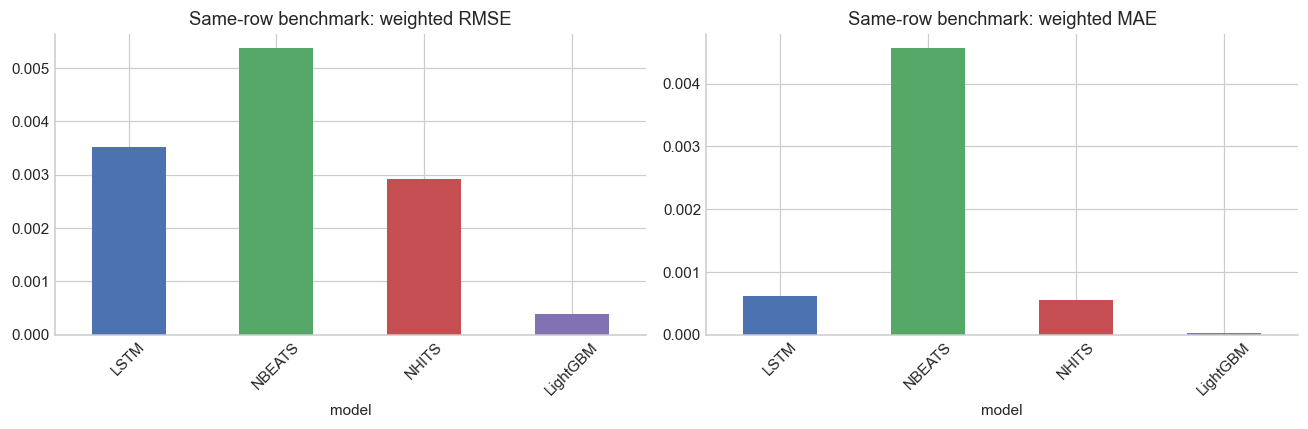

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
benchmark_metrics.set_index('model')['rmse'].plot.bar(ax=axes[0], color=['#4C72B0', '#55A868', '#C44E52', '#8172B3'])
axes[0].set_title('Same-row benchmark: weighted RMSE')
axes[0].tick_params(axis='x', rotation=45)

benchmark_metrics.set_index('model')['mae'].plot.bar(ax=axes[1], color=['#4C72B0', '#55A868', '#C44E52', '#8172B3'])
axes[1].set_title('Same-row benchmark: weighted MAE')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

This section is where the notebook should make the practical point clearly: the DL models are trained correctly and evaluated fairly on their own subset, but the saved `LightGBM` benchmark still has access to richer information and should usually remain the stronger practical model.

## 8. Horizon and sub-category breakdowns

We now test whether the DL ranking changes materially across forecast horizons or sub-categories, or whether the same ordering holds across most of the panel.

In [11]:
horizon_rows = []
for horizon_value, grp in dl_eval.groupby('horizon'):
    row = {'horizon': int(horizon_value)}
    for model in dl_models:
        row[f'{model}_rmse'] = weighted_rmse(grp['y'], grp[model], grp['weight'])
        row[f'{model}_mae'] = weighted_mae(grp['y'], grp[model], grp['weight'])
    horizon_rows.append(row)
horizon_dl = pd.DataFrame(horizon_rows).sort_values('horizon')
horizon_dl

,horizon,LSTM_rmse,LSTM_mae,NBEATS_rmse,NBEATS_mae,NHITS_rmse,NHITS_mae
0,1,0.001997,0.000346,0.005204,0.004534,0.002648,0.000496
1,3,0.003284,0.000602,0.005378,0.004554,0.002974,0.000555
2,10,0.004418,0.000794,0.005549,0.004579,0.003220,0.000591
3,25,0.004788,0.000983,0.005454,0.004593,0.003031,0.000614


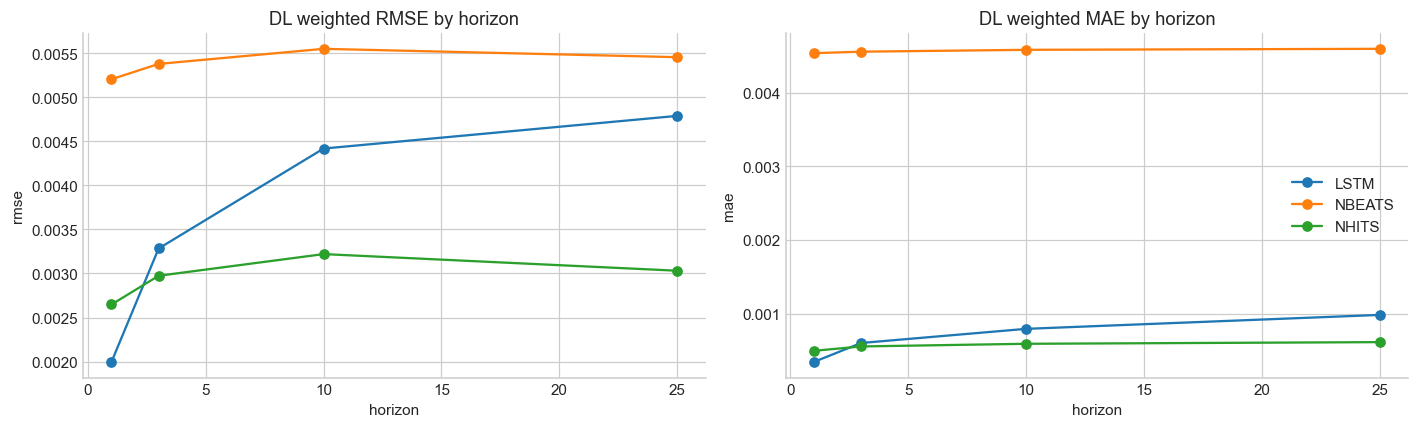

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for model in dl_models:
    axes[0].plot(horizon_dl['horizon'], horizon_dl[f'{model}_rmse'], marker='o', label=model)
    axes[1].plot(horizon_dl['horizon'], horizon_dl[f'{model}_mae'], marker='o', label=model)
axes[0].set_title('DL weighted RMSE by horizon')
axes[0].set_xlabel('horizon')
axes[0].set_ylabel('rmse')
axes[1].set_title('DL weighted MAE by horizon')
axes[1].set_xlabel('horizon')
axes[1].set_ylabel('mae')
axes[1].legend()
plt.tight_layout()
plt.show()

In [13]:
subcat_rows = []
for subcat, grp in dl_eval.groupby('sub_category'):
    row = {'sub_category': subcat}
    for model in dl_models:
        row[f'{model}_rmse'] = weighted_rmse(grp['y'], grp[model], grp['weight'])
        row[f'{model}_mae'] = weighted_mae(grp['y'], grp[model], grp['weight'])
    subcat_rows.append(row)
subcat_dl = pd.DataFrame(subcat_rows).sort_values('sub_category')
subcat_dl

,sub_category,LSTM_rmse,LSTM_mae,NBEATS_rmse,NBEATS_mae,NHITS_rmse,NHITS_mae
0,DPPUO5X2,0.003744,0.000721,0.005423,0.004545,0.003062,0.000605
1,NQ58FVQM,0.003162,0.000537,0.005202,0.004557,0.002613,0.000503
2,PHHHVYZI,0.006822,0.001298,0.007061,0.004652,0.005443,0.001007
3,PZ9S1Z4V,0.003558,0.000663,0.005325,0.004569,0.002810,0.000547
4,V8BKY1IV,0.002604,0.000483,0.005111,0.004544,0.002435,0.000482


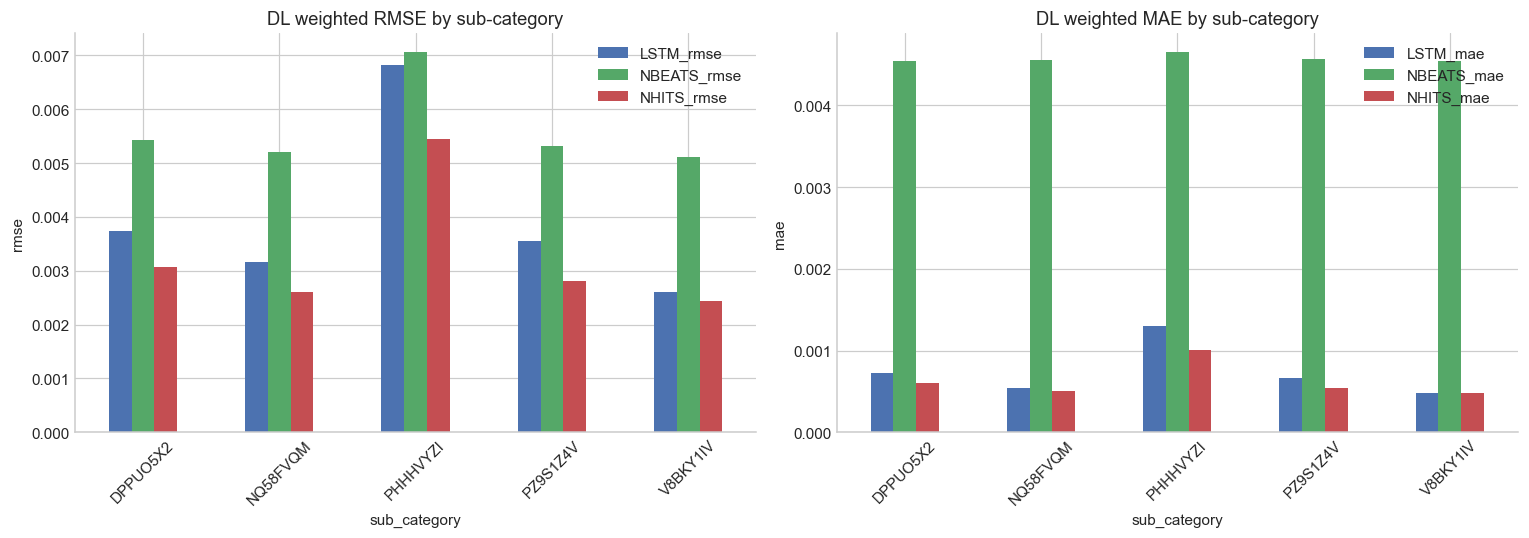

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
subcat_dl.plot(x='sub_category', y=[f'{m}_rmse' for m in dl_models], kind='bar', ax=axes[0], color=['#4C72B0', '#55A868', '#C44E52'])
axes[0].set_title('DL weighted RMSE by sub-category')
axes[0].set_ylabel('rmse')
axes[0].tick_params(axis='x', rotation=45)

subcat_dl.plot(x='sub_category', y=[f'{m}_mae' for m in dl_models], kind='bar', ax=axes[1], color=['#4C72B0', '#55A868', '#C44E52'])
axes[1].set_title('DL weighted MAE by sub-category')
axes[1].set_ylabel('mae')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 9. Representative validation trajectories

Instead of showing the longest arbitrary series, we choose case studies with a purpose: one DL success, one DL failure, one high-weight case, and one relatively stable case. That makes the plots diagnostic rather than decorative.

In [15]:
best_dl_model = deep_metrics.sort_values('rmse').iloc[0]['model']

series_case_stats = (
    same_row_ref.groupby(['unique_id', 'code', 'sub_code', 'sub_category', 'horizon'])
                .agg(
                    total_weight=('weight', 'sum'),
                    target_std=('y', 'std'),
                    ds_min=('ds', 'min'),
                    ds_max=('ds', 'max'),
                )
                .reset_index()
)
for model in dl_models:
    per_series = same_row_ref.groupby('unique_id').apply(lambda g: weighted_mae(g['y'], g[model], g['weight'])).rename(f'{model}_mae').reset_index()
    series_case_stats = series_case_stats.merge(per_series, on='unique_id', how='left')
if 'lgb_pred' in same_row_ref.columns:
    lgb_mae = same_row_ref.groupby('unique_id').apply(lambda g: weighted_mae(g['y'], g['lgb_pred'], g['weight'])).rename('LightGBM_mae').reset_index()
    series_case_stats = series_case_stats.merge(lgb_mae, on='unique_id', how='left')
series_case_stats['target_std'] = series_case_stats['target_std'].fillna(0.0)

stable_pool = series_case_stats[series_case_stats['target_std'] > 0].copy()
used_ids = set()
selected_rows = []

def add_case(df, sort_col, ascending, reason):
    pool = df[~df['unique_id'].isin(used_ids)].sort_values(sort_col, ascending=ascending)
    if not pool.empty:
        row = pool.iloc[[0]].assign(reason=reason)
        selected_rows.append(row)
        used_ids.add(row.iloc[0]['unique_id'])

add_case(series_case_stats, f'{best_dl_model}_mae', True, f'best {best_dl_model} case')
add_case(series_case_stats, f'{best_dl_model}_mae', False, f'weak {best_dl_model} case')
add_case(series_case_stats, 'total_weight', False, 'highest validation weight')
add_case(stable_pool, 'target_std', True, 'most stable validation series')

case_rows = pd.concat(selected_rows, ignore_index=True)
case_rows[['reason', 'unique_id', 'total_weight', 'target_std', f'{best_dl_model}_mae']]

,reason,unique_id,total_weight,target_std,NHITS_mae
0,best NHITS case,SJZP0OVU__KL66VIS3__NQ58FVQM__1,1.998325e+10,0.000119,0.000213
1,weak NHITS case,QAQDDTPJ__OYJGNSQK__PHHHVYZI__10,2.879245e-01,240.783756,78.645926
2,highest validation weight,SJZP0OVU__KL66VIS3__V8BKY1IV__1,2.035136e+10,0.000139,0.000221
3,most stable validation series,SJZP0OVU__KL66VIS3__V8BKY1IV__3,1.878990e+10,0.000230,0.000255


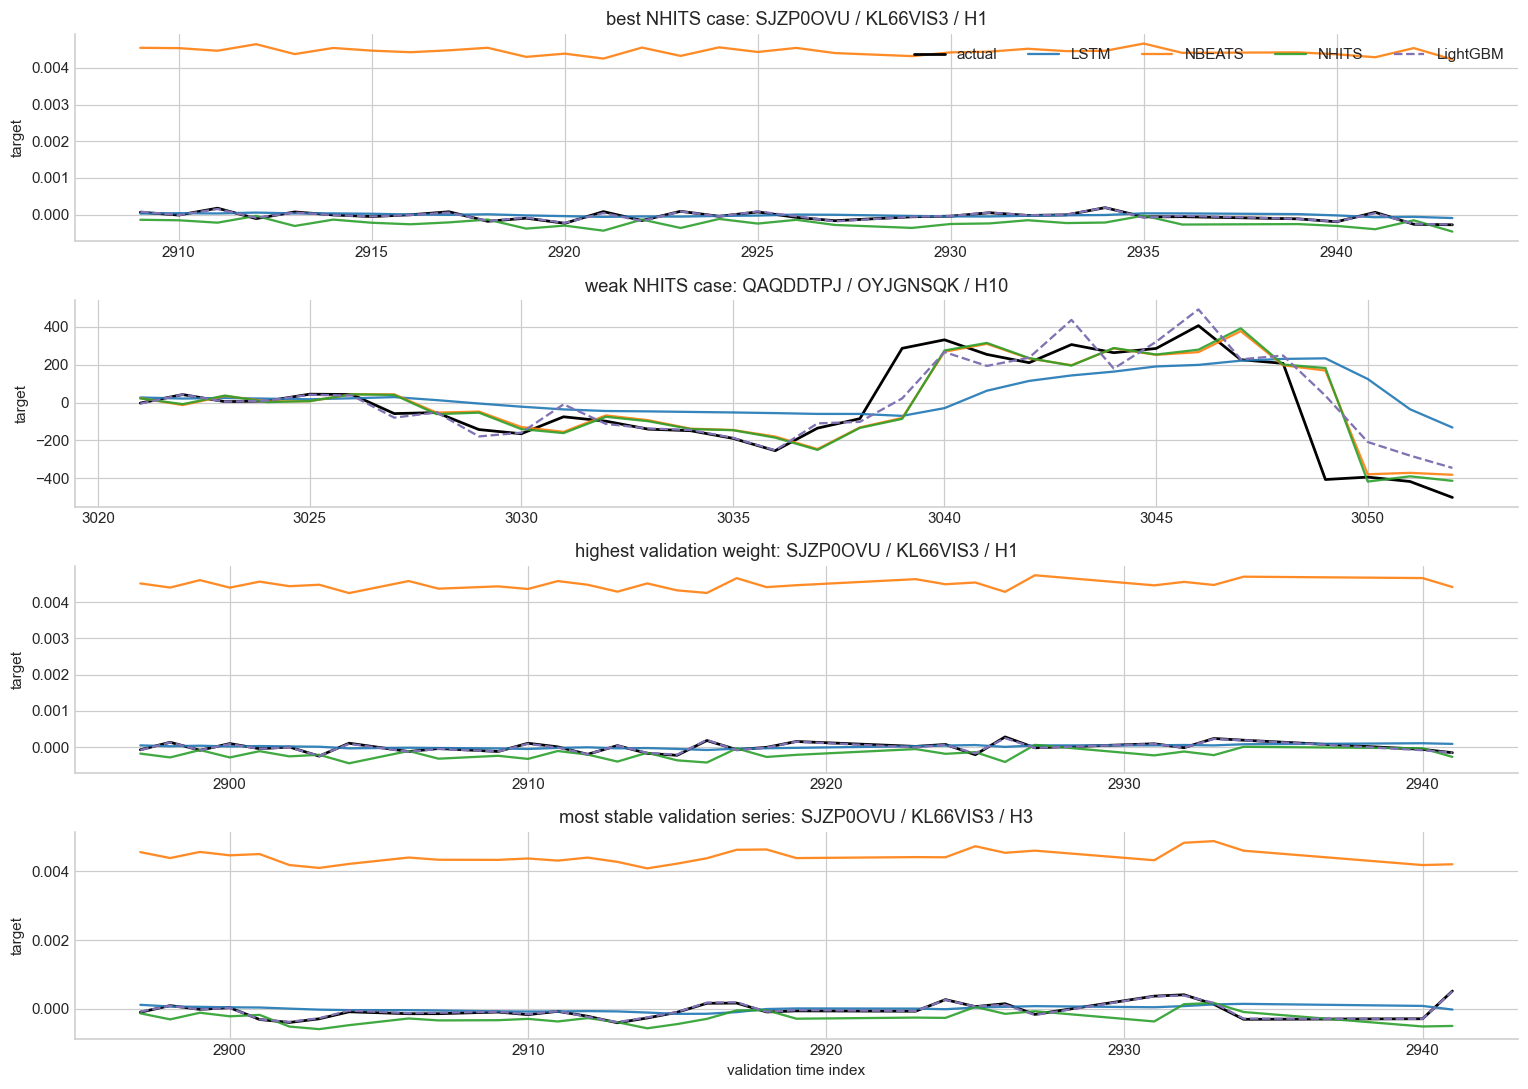

In [16]:
fig, axes = plt.subplots(len(case_rows), 1, figsize=(14, 10), sharex=False)
axes = np.atleast_1d(axes)
for ax, row in zip(axes, case_rows.itertuples(index=False)):
    s = same_row_ref[same_row_ref['unique_id'] == row.unique_id].sort_values('ds')
    ax.plot(s['ds'], s['y'], label='actual', linewidth=1.8, color='black')
    ax.plot(s['ds'], s['LSTM'], label='LSTM', alpha=0.9)
    ax.plot(s['ds'], s['NBEATS'], label='NBEATS', alpha=0.9)
    ax.plot(s['ds'], s['NHITS'], label='NHITS', alpha=0.9)
    if 'lgb_pred' in s.columns and s['lgb_pred'].notna().all():
        ax.plot(s['ds'], s['lgb_pred'], label='LightGBM', linestyle='--', linewidth=1.5, color='#8172B3')
    ax.set_title(f"{row.reason}: {row.code} / {row.sub_code} / H{row.horizon}")
    ax.set_ylabel('target')
axes[-1].set_xlabel('validation time index')
axes[0].legend(loc='upper right', ncol=5)
plt.tight_layout()
plt.show()

## 10. Residual diagnostics

The next question is not just which model is best, but *how* the weaker models fail. Residual and absolute-error views help distinguish systematic underfitting from occasional large misses.

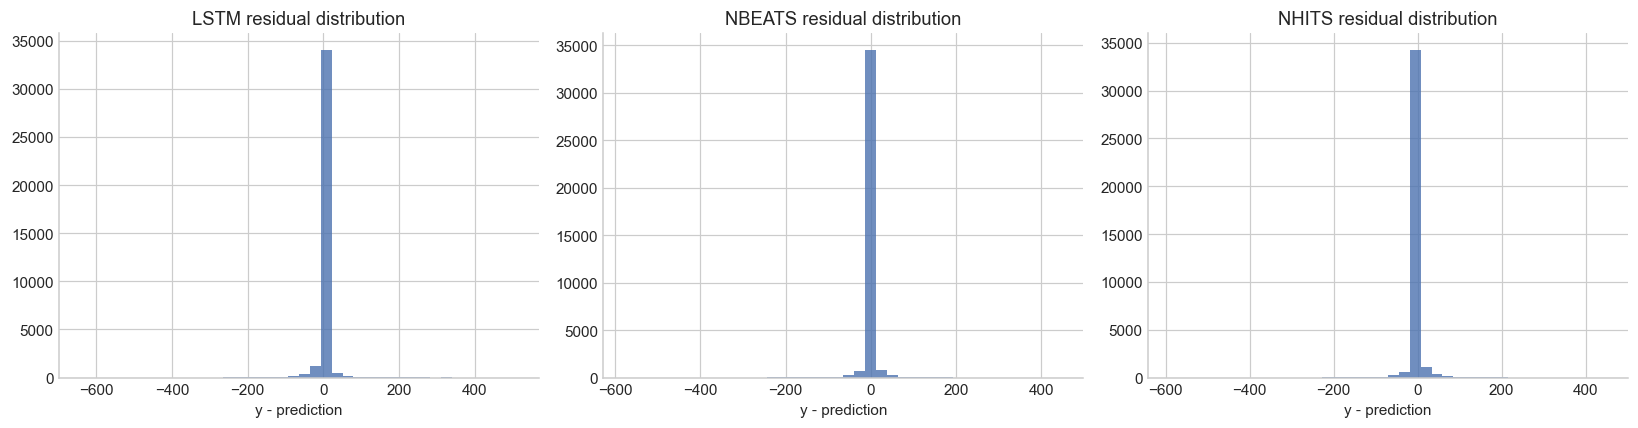

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, model in zip(axes, dl_models):
    residual = dl_eval['y'] - dl_eval[model]
    ax.hist(residual, bins=40, color='#4C72B0', alpha=0.8)
    ax.set_title(f'{model} residual distribution')
    ax.set_xlabel('y - prediction')
plt.tight_layout()
plt.show()

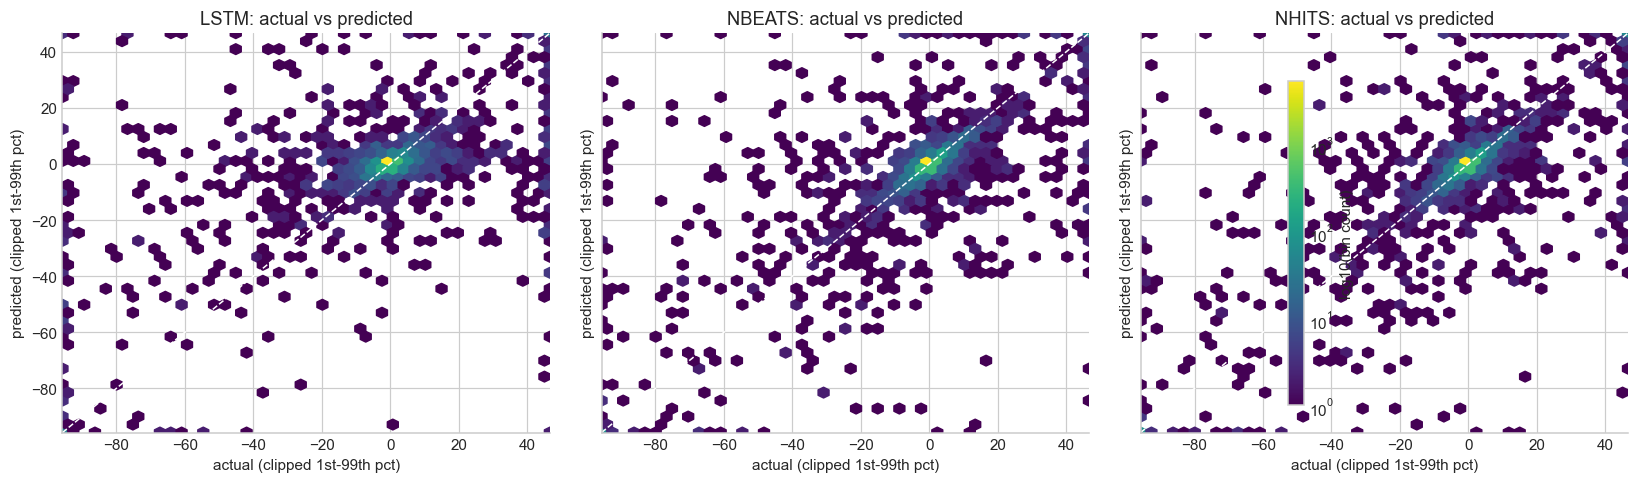

In [18]:
sampled_eval = dl_eval.sample(min(8000, len(dl_eval)), random_state=SEED).copy()
plot_values = sampled_eval[['y', *dl_models]].stack()
lo = float(plot_values.quantile(0.01))
hi = float(plot_values.quantile(0.99))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)
last_hb = None
for ax, model in zip(axes, dl_models):
    x = sampled_eval['y'].clip(lo, hi)
    yhat = sampled_eval[model].clip(lo, hi)
    last_hb = ax.hexbin(x, yhat, gridsize=45, cmap='viridis', bins='log', mincnt=1)
    ax.plot([lo, hi], [lo, hi], linestyle='--', color='white', linewidth=1)
    ax.set_title(f'{model}: actual vs predicted')
    ax.set_xlabel('actual (clipped 1st-99th pct)')
    ax.set_ylabel('predicted (clipped 1st-99th pct)')
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

fig.colorbar(last_hb, ax=axes, shrink=0.85, label='log10(bin count)')
plt.tight_layout()
plt.show()

## 11. Why DL still trails ML here

This notebook should not hide the main practical conclusion. These models are trained correctly and evaluated fairly on a standardized rolling validation subset, but they still work with **target history only**. The saved `LightGBM` benchmark keeps access to richer exogenous information and usually remains the stronger practical forecast on the same rows.

## 12. Probabilistic gap

This notebook remains point-forecast-only.

- No quantile heads are trained.
- No interval columns are produced.
- No forecast bands are plotted.
- No interval metrics such as `PICP`, `MPIW`, or quantile loss are reported.

That is a scope choice for this project stage, not an accidental omission in the notebook.

## 13. Takeaways

- `04_deep_learning.ipynb` is now a real retrain notebook built from raw data rather than a thin saved-artifact summary.
- The DL evaluation is standardized to series with enough pre-cutoff context and a common `32`-step post-cutoff window.
- `LSTM`, `NBEATS`, and `NHITS` can now be compared on fresh rolling validation predictions with weighted RMSE and MAE.
- The same-row `LightGBM` benchmark makes the DL vs ML gap concrete instead of only discussing it abstractly.
- This notebook still studies point forecasts only; probabilistic DL remains a future extension rather than something implied by the current results.